In [1]:
import os
os.chdir('../../../../..')

In [2]:
import numpy as np

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN, KMeans
from kmedoids import KMedoids

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster

In [3]:
qm9 = QM9Dataset(limit=5000, sampling_strategy="stratified", stratify_by=["num_atoms", "gap"], add_chemprop=True)
df = qm9.load()
molecules = qm9.get_molecules()

2026-04-17 15:26:59.099 | INFO     | src.datasets:load:494 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-04-17 15:26:59.299 | INFO     | src.datasets:_sample_qm9_df:686 - QM9 sampling complete: strategy=stratified, requested_limit=5000, returned_rows=5000.
2026-04-17 15:26:59.299 | INFO     | src.datasets:_add_requested_descriptors:127 - Applying requested QM9 descriptors to sampled dataframe (rows=5000).
2026-04-17 15:26:59.299 | INFO     | src.features:compute_chemprop_embeddings:284 - Computing Chemprop embeddings on mps...
2026-04-17 15:26:59.300 | WARNING  | src.features:compute_chemprop_embeddings:292 - No model_path provided. Using RANDOM (untrained) MPNN weights.
2026-04-17 15:27:02.362 | INFO     | src.datasets:_add_requested_descriptors:150 - Added descriptor column(s): ['chemprop_embedding']
2026-04-17 15:27:46.105 | SUCCESS  | src.datasets:get_molecules:1171 - Saved 5000 molecules to data/QM9/qm9_subset.xyz (failed: 0, requested: 5000).
2026-

In [4]:
len(df['chemprop_embedding'].to_list()[0])

25

In [5]:
len(molecules[0:2])

2

In [6]:
plot_molecules_with_py3dmol(molecules[0:3])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [7]:
dist_matrix = qm9.get_distance_matrix(
    descriptor="chemprop",
    dist_type="euclidean",
)

2026-04-17 15:27:50.671 | INFO     | src.datasets:get_distance_matrix:1002 - Calculating distance matrix for chemprop using euclidean distance.
2026-04-17 15:27:50.759 | INFO     | src.distance:get_matrix:29 - Loading cached distance matrix from data/QM9/dist_chemprop_euclidean.npy


# Determining the best number of clusters for each clustering method

Evaluating epsilon and min samples: 100%|██████████| 10/10 [00:10<00:00,  1.07s/it]


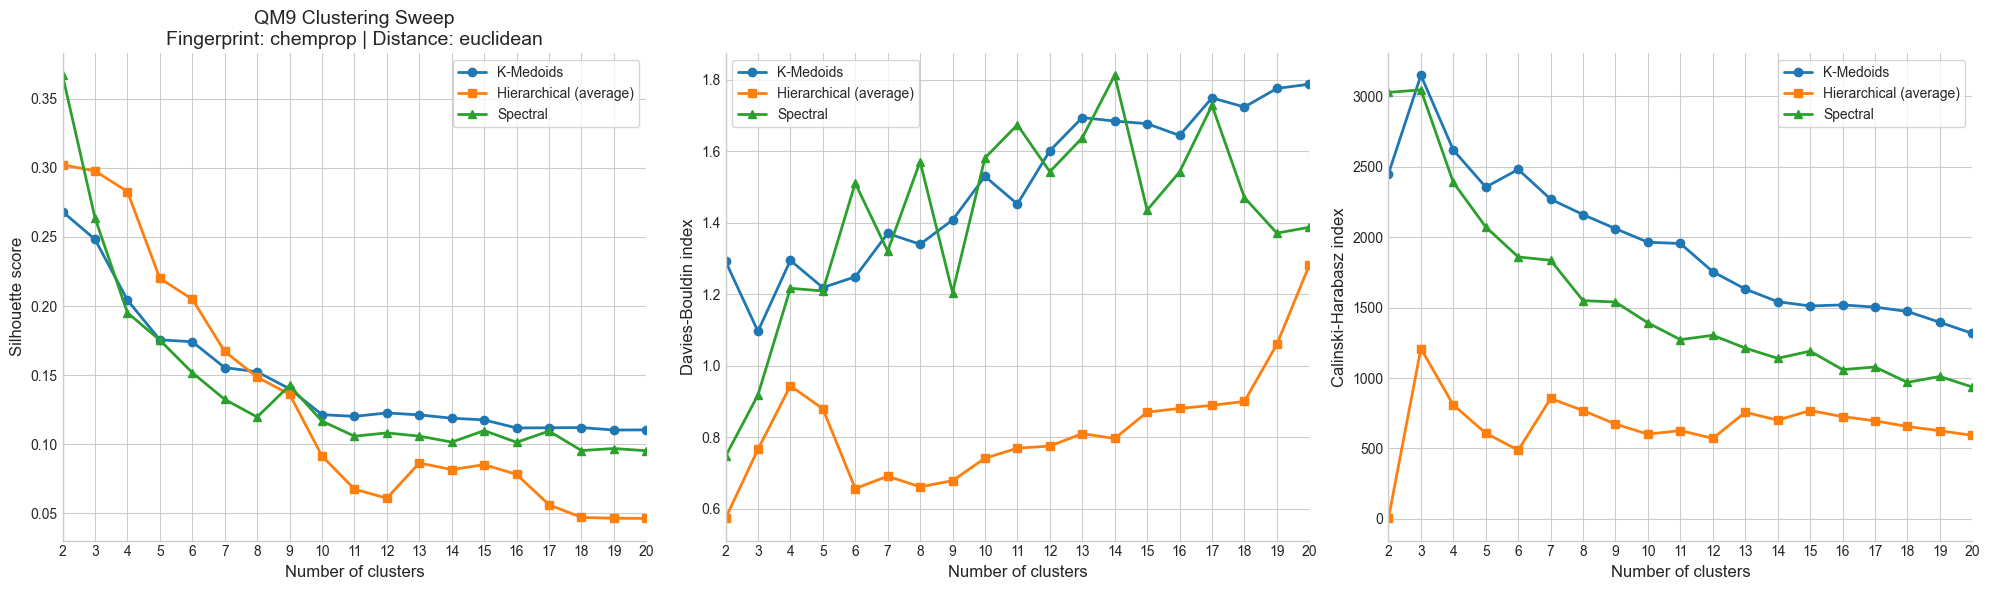

2026-04-17 15:29:28.752 | WARNING  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:818 - No valid DBSCAN parameter combinations produced clusterings to plot.
2026-04-17 15:29:28.755 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:840 - Saved clustering sweep plot to figures/qm9/clustering/euclidean/chemprop/clustering_sweep_2_to_20_clusters.png
2026-04-17 15:29:28.756 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:843 - Saved clustering sweep results to figures/qm9/clustering/euclidean/chemprop/clustering_sweep_2_to_20_clusters.json


In [8]:
out = evaluate_distance_matrix_clustering_sweep(
    dist_matrix=dist_matrix,
    fingerprint="chemprop",
    distance_metric="euclidean",
    dataset_name="qm9",
)

In [9]:
# find the n molecules that are not on the diagonal with the smallest distance
n = 10
# Get the indices of the upper triangle (excluding diagonal)
triu_indices = np.triu_indices_from(dist_matrix, k=1)
# Get the distances and corresponding molecule pairs
distances = dist_matrix[triu_indices]
molecule_pairs = list(zip(triu_indices[0], triu_indices[1]))
# Get the indices of the n smallest distances
smallest_indices = np.argsort(distances)[:n]
# Get the corresponding molecule pairs for the n smallest distances
closest_pairs = [molecule_pairs[i] for i in smallest_indices]
print("Closest molecule pairs (indices):", closest_pairs)
mols = [(molecules[idx1], molecules[idx2]) for idx1, idx2 in closest_pairs]

Closest molecule pairs (indices): [(np.int64(1332), np.int64(1333)), (np.int64(1648), np.int64(1685)), (np.int64(1195), np.int64(1196)), (np.int64(1151), np.int64(1241)), (np.int64(3876), np.int64(3878)), (np.int64(4552), np.int64(4691)), (np.int64(3438), np.int64(3764)), (np.int64(1816), np.int64(1883)), (np.int64(4533), np.int64(4658)), (np.int64(2975), np.int64(2988))]


In [10]:
print(mols[0])

(Atoms(symbols='HC2H6C3N2C2', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='H9C2NC3NC2', pbc=False, initial_charges=..., mass=..., partial_charge=...))


In [11]:
plot_molecules_with_py3dmol(mols[1])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# Hiercical Clustering on Distance Matrix

In [30]:
model_hier = AgglomerativeClustering(metric='precomputed', n_clusters=3, linkage='complete')
labels_hier = model_hier.fit_predict(dist_matrix)
df = df.with_columns(labels_hier=labels_hier)
print(np.unique(labels_hier, return_counts=True))

(array([0, 1, 2]), array([4092,  175,  733]))


In [13]:
create_chemiscope_viewer(df, dist_matrix, labels_hier, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [14]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="chemprop",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_hier,
    clustering_method="hierarchical"
)

2026-04-17 15:29:58.080 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/euclidean/chemprop/pca_hierarchical_projection.png


{'coords': array([[-0.14835068, -0.26440646],
        [ 1.99651962,  2.42082595],
        [-0.64568236,  0.81006212],
        ...,
        [-2.94162118, -0.41312393],
        [-2.97687284, -0.21930617],
        [-2.93635826,  0.11000044]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/chemprop/pca_hierarchical_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/chemprop'),
 'clustering_method': 'hierarchical'}

In [15]:
average_numeric_by_cluster(df, "labels_hier")

shape: (3, 59)
┌─────────────┬───────┬─────────────────────┬───────────┬────────────┬─────────┬─────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────────┬────────┬─────────┬─────────┬────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬────────────────────┬──────────────┬─────────────┐
│ labels_hier ┆ count ┆ token_to_atom_ratio ┆ num_atoms ┆ mol_weight ┆ logp    ┆ tpsa    ┆ election_affinity ┆ ionization_energies ┆ num_heavy_atoms ┆ num_rings

# KMedoids

In [16]:
model_km = KMedoids(n_clusters=3, metric="precomputed")
labels_km = model_km.fit_predict(dist_matrix)
df = df.with_columns(labels_km=labels_km)

In [17]:
create_chemiscope_viewer(df, dist_matrix, labels_km, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [18]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="chemprop",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_km,
    clustering_method="kmedoids"
)

2026-04-17 15:30:24.251 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/euclidean/chemprop/pca_kmedoids_projection.png


{'coords': array([[-0.14835068, -0.26440646],
        [ 1.99651962,  2.42082595],
        [-0.64568236,  0.81006212],
        ...,
        [-2.94162118, -0.41312393],
        [-2.97687284, -0.21930617],
        [-2.93635826,  0.11000044]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/chemprop/pca_kmedoids_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/chemprop'),
 'clustering_method': 'kmedoids'}

In [19]:
average_numeric_by_cluster(df, "labels_km")

shape: (3, 60)
┌───────────┬───────┬─────────────────────┬───────────┬────────────┬────────┬─────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────────┬────────┬─────────┬─────────┬────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬────────────────────┬──────────────┬─────────────┐
│ labels_km ┆ count ┆ token_to_atom_ratio ┆ num_atoms ┆ mol_weight ┆ logp   ┆ tpsa    ┆ election_affinity ┆ ionization_energies ┆ num_heavy_atoms ┆ n

# Spectral

In [20]:
model_spectral = SpectralClustering(
                n_clusters=3,
                affinity="precomputed",
                assign_labels='kmeans',
                random_state=42,
            )

labels_spectral = model_spectral.fit_predict(dist_matrix)
df = df.with_columns(labels_spectral=labels_spectral)

In [21]:
create_chemiscope_viewer(df, dist_matrix, labels_spectral, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [31]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="chemprop",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_spectral,
    clustering_method="spectral"
)

2026-04-17 15:42:35.247 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/euclidean/chemprop/pca_spectral_projection.png


{'coords': array([[-0.14835068, -0.26440646],
        [ 1.99651962,  2.42082595],
        [-0.64568236,  0.81006212],
        ...,
        [-2.94162118, -0.41312393],
        [-2.97687284, -0.21930617],
        [-2.93635826,  0.11000044]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/chemprop/pca_spectral_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/chemprop'),
 'clustering_method': 'spectral'}

In [32]:
average_numeric_by_cluster(df, "labels_spectral")

shape: (3, 63)
┌─────────────────┬───────┬─────────────────────┬───────────┬────────────┬─────────┬─────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────────┬────────┬─────────┬─────────┬────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬───────────┬───────────────────┬────────────────────┬──────────────┬─────────────┐
│ labels_spectral ┆ count ┆ token_to_atom_ratio ┆ num_atoms ┆ mol_weight ┆ logp    ┆ tpsa    ┆ ele

# DBSCAN 

In [41]:
model_db = DBSCAN(
    eps=0.066,
    min_samples=2,
    metric='precomputed',
)

labels_db = model_db.fit_predict(dist_matrix)
df = df.with_columns(labels_db=labels_db)
print(np.unique(labels_db, return_counts=True))

(array([-1,  0,  1,  2,  3,  4,  5]), array([  50, 4940,    2,    2,    2,    2,    2]))


In [42]:
create_chemiscope_viewer(df, dist_matrix, labels_db, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [43]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="chemprop",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_db,
    clustering_method="dbscan"
)

2026-04-17 15:54:07.662 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/euclidean/chemprop/pca_dbscan_projection.png


{'coords': array([[-0.14835068, -0.26440646],
        [ 1.99651962,  2.42082595],
        [-0.64568236,  0.81006212],
        ...,
        [-2.94162118, -0.41312393],
        [-2.97687284, -0.21930617],
        [-2.93635826,  0.11000044]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/chemprop/pca_dbscan_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/chemprop'),
 'clustering_method': 'dbscan'}

In [44]:
average_numeric_by_cluster(df, "labels_db")

shape: (7, 63)
┌───────────┬───────┬─────────────────────┬───────────┬────────────┬─────────┬─────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬─────────────────┬───────────────────┬────────────────────┬──────────────┬─────────────┐
│ labels_db ┆ count ┆ token_to_atom_ratio ┆ num_atoms ┆ mol_weight ┆ logp    ┆ tpsa    ┆ election

# KMeans on Raw Embeddings


In [28]:
X_raw = np.array(df["chemprop_embedding"].to_list(), dtype=np.float32)
kmeans_raw = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_kmeans_raw = kmeans_raw.fit_predict(X_raw)
df = df.with_columns(labels_kmeans_raw=labels_kmeans_raw)


In [29]:
average_numeric_by_cluster(df, "labels_kmeans_raw")


shape: (2, 63)
┌───────────────────┬───────┬─────────────────────┬───────────┬────────────┬────────┬─────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────┐
│ labels_kmeans_raw ┆ count ┆ token_to_atom_ratio ┆ num_atoms ┆ mol_weight ┆ logp   ┆ tpsa    ┆ el